# CAB420 Assignment 1A Question 1: Template
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a brief template for CAB420 Assignment 1A, Question 1. It implements the data loading, and splitting the data into the predictors and response. You are to use the data splits defined here in your response.

The template also provides other suggestions around how to approach the problem.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns;
from statsmodels import api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score
import os
from datetime import datetime, date
import itertools

Mounted at /content/drive


In [ ]:
# load data
train = pandas.read_csv('/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_1A/Q1/communities_train.csv')
val = pandas.read_csv('/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_1A/Q1/communities_val.csv')
test = pandas.read_csv('/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_1A/Q1/communities_test.csv')

# Pull out X and y components of the data
# if you want to convert this data to numpy format, you can add .to_numpy() to the end of each row below
X_train = train.iloc[:,0:-1]
Y_train = train.iloc[:,-1]
X_val = val.iloc[:,0:-1]
Y_val = val.iloc[:,-1]
X_test = test.iloc[:,0:-1]
Y_test = test.iloc[:,-1]
#print("X-TRAIN\n", X_train, "\n\n")
#print("Y-TRAIN\n", y_train, "\n\n")
#print("X-VAL\n", X_val, "\n\n")
#rint("Y-VAL\n", y_val, "\n\n")
#print("X-TEST\n", X_test, "\n\n")
#print("Y-TEST\n", y_test, "\n\n")
def standardise(data):
  """ Standardise/Normalise data to have zero mean and unit variance

  Args:
    data (np.array):
      data we want to standardise (usually covariates)

    Returns:
      Standardised data, mean of data, standard deviation of data
  """
  mu = np.mean(data, axis=0)
  sigma = np.std(data, axis=0)
  scaled = (data - mu) / sigma
  return scaled, mu, sigma

X_train_std, mu_train_x, sigma_train_x = standardise(X_train)
Y_train_std, mu_train_y, sigma_train_y = standardise(Y_train)
X_val_std = (X_val - mu_train_x)/sigma_train_x
Y_val_std = (Y_val - mu_train_y)/sigma_train_y
X_test_std = (X_test - mu_train_x)/sigma_train_x
Y_test_std = (Y_test - mu_train_y)/sigma_train_y

In [ ]:
# If you wish to pre-process the data, do so here. In your write-up, outline why you choose to do, or choose not to do, any
# pre-processing

Model LR RMSE = 0.7297
Model LR R² Score = 0.7591
                                  OLS Regression Results                                  
Dep. Variable:      ViolentCrimesPerPop    R-squared (uncentered):                   0.759
Model:                               OLS   Adj. R-squared (uncentered):              0.637
Method:                    Least Squares   F-statistic:                              6.239
Date:                   Sat, 05 Apr 2025   Prob (F-statistic):                    4.63e-28
Time:                           09:35:57   Log-Likelihood:                         -210.77
No. Observations:                    298   AIC:                                      621.5
Df Residuals:                        198   BIC:                                      991.2
Df Model:                            100                                                  
Covariance Type:               nonrobust                                                  
                              coef    st

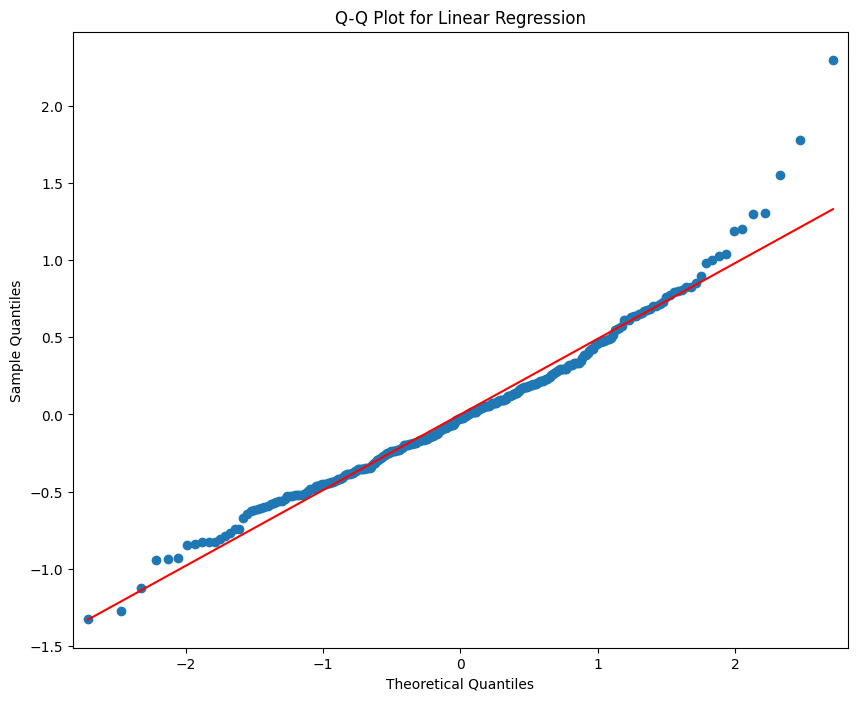

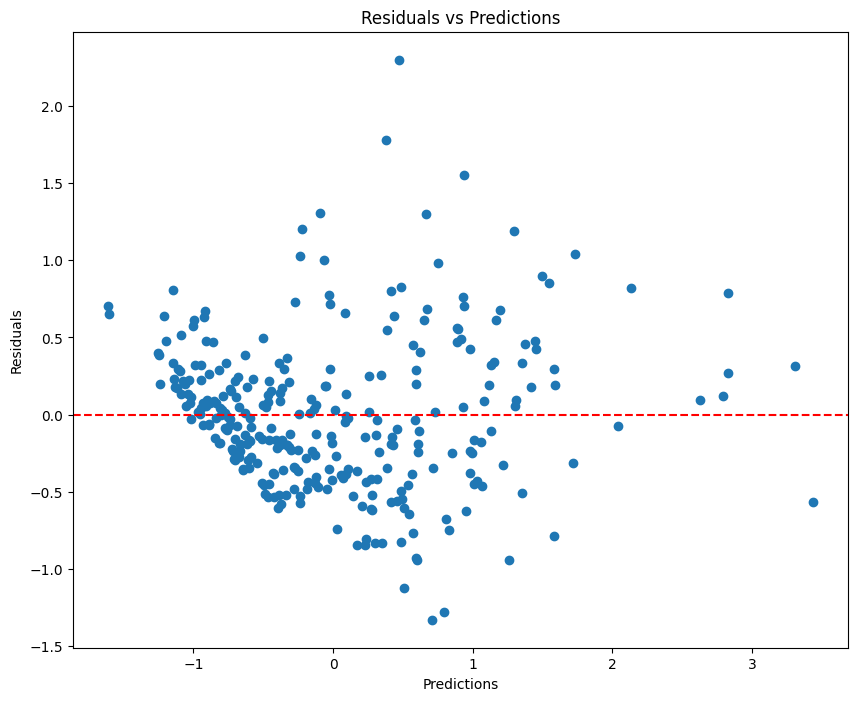

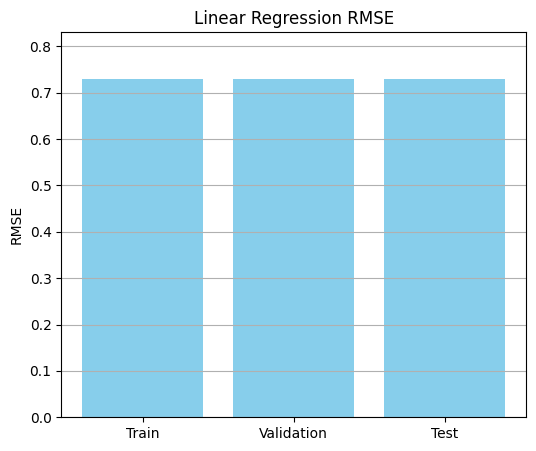

In [ ]:
# train your Linear Regression model here. Data has already been split into predictors (X_train, X_val and X_test) and the
# desired response (y_train, y_val and y_test above).
#
# Note that you DO NOT NEED to remove any variables, or add higher order terms. JUST USE THE DATA AS IS.
#
LRMODEL = sm.OLS(Y_train_std, X_train_std)
model_LR_fit = LRMODEL.fit()
pred = model_LR_fit.predict(X_val_std)

# Measuring the accuracy of the model (i.e. RMSE or similar measures)
rmse = np.sqrt(mean_squared_error(Y_val_std, pred))
print(f'Model LR RMSE = {rmse:.4f}')
r2 = model_LR_fit.rsquared
print(f'Model LR R² Score = {r2:.4f}')

# Looking at the properties of the fitted model, for example the R^2, and if all terms are contributing to the model
print(model_LR_fit.summary())

# Q-Q Plot (Checking normality of residuals)
fig, ax = plt.subplots(figsize=(10,8))
sm.qqplot(model_LR_fit.resid, ax=ax, line='s')
plt.title('Q-Q Plot for Linear Regression')
plt.show()

# Residuals vs. Predictions Plot (Checking homoscedasticity)
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(model_LR_fit.predict(X_train_std), model_LR_fit.resid)
ax.set_xlabel('Predictions')
ax.set_ylabel('Residuals')
ax.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predictions')
plt.show()

# Plot
plt.figure(figsize=(6, 5))
plt.bar(['Train', 'Validation', 'Test'], [train_rmse_linear, val_rmse_linear, test_rmse_linear], color='skyblue')
plt.title('Linear Regression RMSE')
plt.ylabel('RMSE')
plt.grid(axis='y')
plt.ylim(0, max(train_rmse_linear, val_rmse_linear, test_rmse_linear) + 0.1)
plt.show()

# Once you've trained the model, evaluate it. This would include:
#  - Measuring the accuracy of the model (i.e. RMSE or similar measures)
#  - Looking at the properties of the fitted model, for example the R^2, and if all terms are contributing to the model
#  - Considering the validity of the trained model. This could include assumptions about independent predictors, and the
#    distribution of the residuals
# Your write-up should include your findings regarding the above.

In [ ]:
# train your regularised models (ridge and lasso). Here you will use the same data as you used in for the above regression model
#
# One key consideration with your regularised models is the selection of lambda (i.e. the strength of the regularisation). A suggested
# starting point for finding your value of lambda is suggested below using numpy.logspace (see
# https://numpy.org/doc/stable/reference/generated/numpy.logspace.html). The code below will give you 50 values starting at 10-10 and
# finishing at 1, spread on a log scale. Just note that for plotting things that result from this, you may want to change the scale of
# your x-axis to a log scale (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html)
#
# Note that the below list of lambda is going to be fairly coarse. For the sake of speed, we suggest that you avoid evaluating a huge
# number of lambdas in one pass, but you can get a more precise estimate by refining your estimate over multiple passes (i.e. if your
# initial estimate if 0.1, you could run the search again now looking over a range of [0.01 .. 1.0] or similar). If you wish to do this,
# we suggest limiting yourself to 2-3 passes at most. You do not need to get the perfect value of lambda.
#
# remember that lambda is a keyword in python, so we're calling the array below alphas.
#

def rmse(actual, pred):
  return np.sqrt(mean_squared_error(actual, pred))

def r_squared(actual, predicted):
  r2 = r2_score(actual, predicted)
  return r2

def adj_r2(actual, predicted, n, p):
  r2 = r2_score(actual, predicted)
  adjr2 = 1 - (1 - r2) * (n - 1) / (n - p - 1);
  return adjr2

def evaluate_regularisation(x_train, y_train, x_val, y_val, x_test, y_test,
                            response_mu, response_sigma, alpha_list, L1_L2):

  # Ridge: L1_L2 = 0
  # Lasso: L1_L2 = 1
  model = sm.OLS(y_train, x_train)
  best_rmse = 10e12
  best_alpha = []
  best_coeffs = []
  rmse_val = []
  rmse_train = []
  coeffs = []
  for alpha in alpha_list:
    model_cross_fit = model.fit_regularized(alpha=alpha, L1_wt=L1_L2)
    train_pred = model_cross_fit.predict(x_train)
    val_pred = model_cross_fit.predict(x_val)
    rmse_train.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    rmse_val.append(np.sqrt(mean_squared_error(y_val, val_pred)))
    coeffs.append(model_cross_fit.params)
    if rmse_val[-1] < best_rmse:
      best_rmse = rmse_val[-1]
      best_alpha = alpha
      best_coeffs = model_cross_fit.params

  print('Best values on Validation Data set')
  slope = np.array(best_coeffs[0:]).reshape(-1, 1)
  pred_val_rescaled = (x_val @ slope) * response_sigma + response_mu
  pred_test_rescaled = (x_test @ slope) * response_sigma + response_mu
  pred_train_rescaled = (x_train @ slope) * response_sigma + response_mu
  best_r2 = r_squared(y_train * response_sigma + response_mu, pred_train_rescaled)
  best_adj_r2 = adj_r2(y_train * response_sigma + response_mu, pred_train_rescaled,x_train.shape[0], x_train.shape[1])
  best_val_rmse = np.sqrt(mean_squared_error(y_val* response_sigma + response_mu, pred_val_rescaled))
  best_test_rmse = np.sqrt(mean_squared_error(y_test* response_sigma + response_mu, pred_test_rescaled))
  print('Best Alpha ={}'.format(best_alpha))
  print('Best R Squared = {}'.format(best_r2))
  print('Best Adjusted = {}'.format(best_adj_r2))
  print('Best RMSE (val) = {}'.format(best_val_rmse))
  print('Best RMSE (test) = {}'.format(best_test_rmse))
  print('Best coefficients on the normalised model')
  print('Best slope = {}'.format(slope))

  fig, axs = plt.subplots(5, figsize=(15, 25))
  axs[0].plot(np.array(alpha_list), rmse_train)
  axs[0].plot(np.array(alpha_list), rmse_val)
  axs[0].legend(['Training', 'Validation'])
  axs[0].set_title('RMSE vs Lambda')
  axs[0].set_xlabel('Lambda')
  axs[0].set_ylabel('RMSE')

  # plot prediction and true values for test set
  axs[1].plot((Y_test_std*response_sigma + response_mu))
  axs[1].plot((X_test_std @ slope) * response_sigma + response_mu)
  axs[1].legend(['Actual', 'Predicted'])
  axs[1].set_title('Test Set Performance')

  # plotting the Q-Q plot
  train_pred = (X_train_std @ slope).values.reshape(Y_train.shape)
  resid = Y_train_std - train_pred
  sm.qqplot(resid, ax=axs[2], line='s')
  axs[2].set_title('Q-Q Plot for Linear Regression')

  # plot the residuals as well
  axs[3].scatter(train_pred, resid)
  axs[3].set_title('Residuals for training set')
  axs[3].set_xlabel('Predicted')
  axs[3].set_ylabel('Residuals')

  # trace plot of coefficients
  axs[4].plot(np.array(alpha_list), coeffs)
  axs[4].set_title('Trace PLot of Coefficients')
  axs[4].set_xlabel('Lambda')
  axs[4].set_ylabel('Coefficient Value')

alphas = np.logspace(-10, 0, 100)

RIDGE:
Best values on Validation Data set
Best Alpha =0.06135907273413163
Best R Squared = 0.7182056062081854
Best Adjusted = 0.5751627667199547
Best RMSE (val) = 0.14247714909139023
Best RMSE (test) = 0.1314902865929718
Best coefficients on the normalised model
Best slope = [[ 0.00650059]
 [-0.08167352]
 [ 0.08767966]
 [-0.05379543]
 [ 0.00167991]
 [-0.1727523 ]
 [-0.05924753]
 [ 0.0431688 ]
 [ 0.06477023]
 [ 0.05995393]
 [ 0.00119354]
 [ 0.07449195]
 [ 0.05078198]
 [-0.04966269]
 [ 0.01421943]
 [-0.10514518]
 [ 0.06494907]
 [ 0.04697388]
 [-0.08537156]
 [ 0.02281587]
 [ 0.00883823]
 [ 0.00758319]
 [-0.00235038]
 [-0.03513839]
 [ 0.08740431]
 [ 0.00622115]
 [ 0.05254893]
 [-0.02240271]
 [-0.10877903]
 [-0.04435614]
 [ 0.03114455]
 [ 0.03405587]
 [-0.09853303]
 [ 0.13066175]
 [-0.07765149]
 [-0.00960131]
 [ 0.01209258]
 [-0.02673319]
 [-0.01851433]
 [ 0.00829155]
 [-0.00515128]
 [-0.00963453]
 [ 0.06621344]
 [-0.09871163]
 [-0.11782739]
 [-0.0779052 ]
 [-0.01996146]
 [ 0.06039611]
 [-0

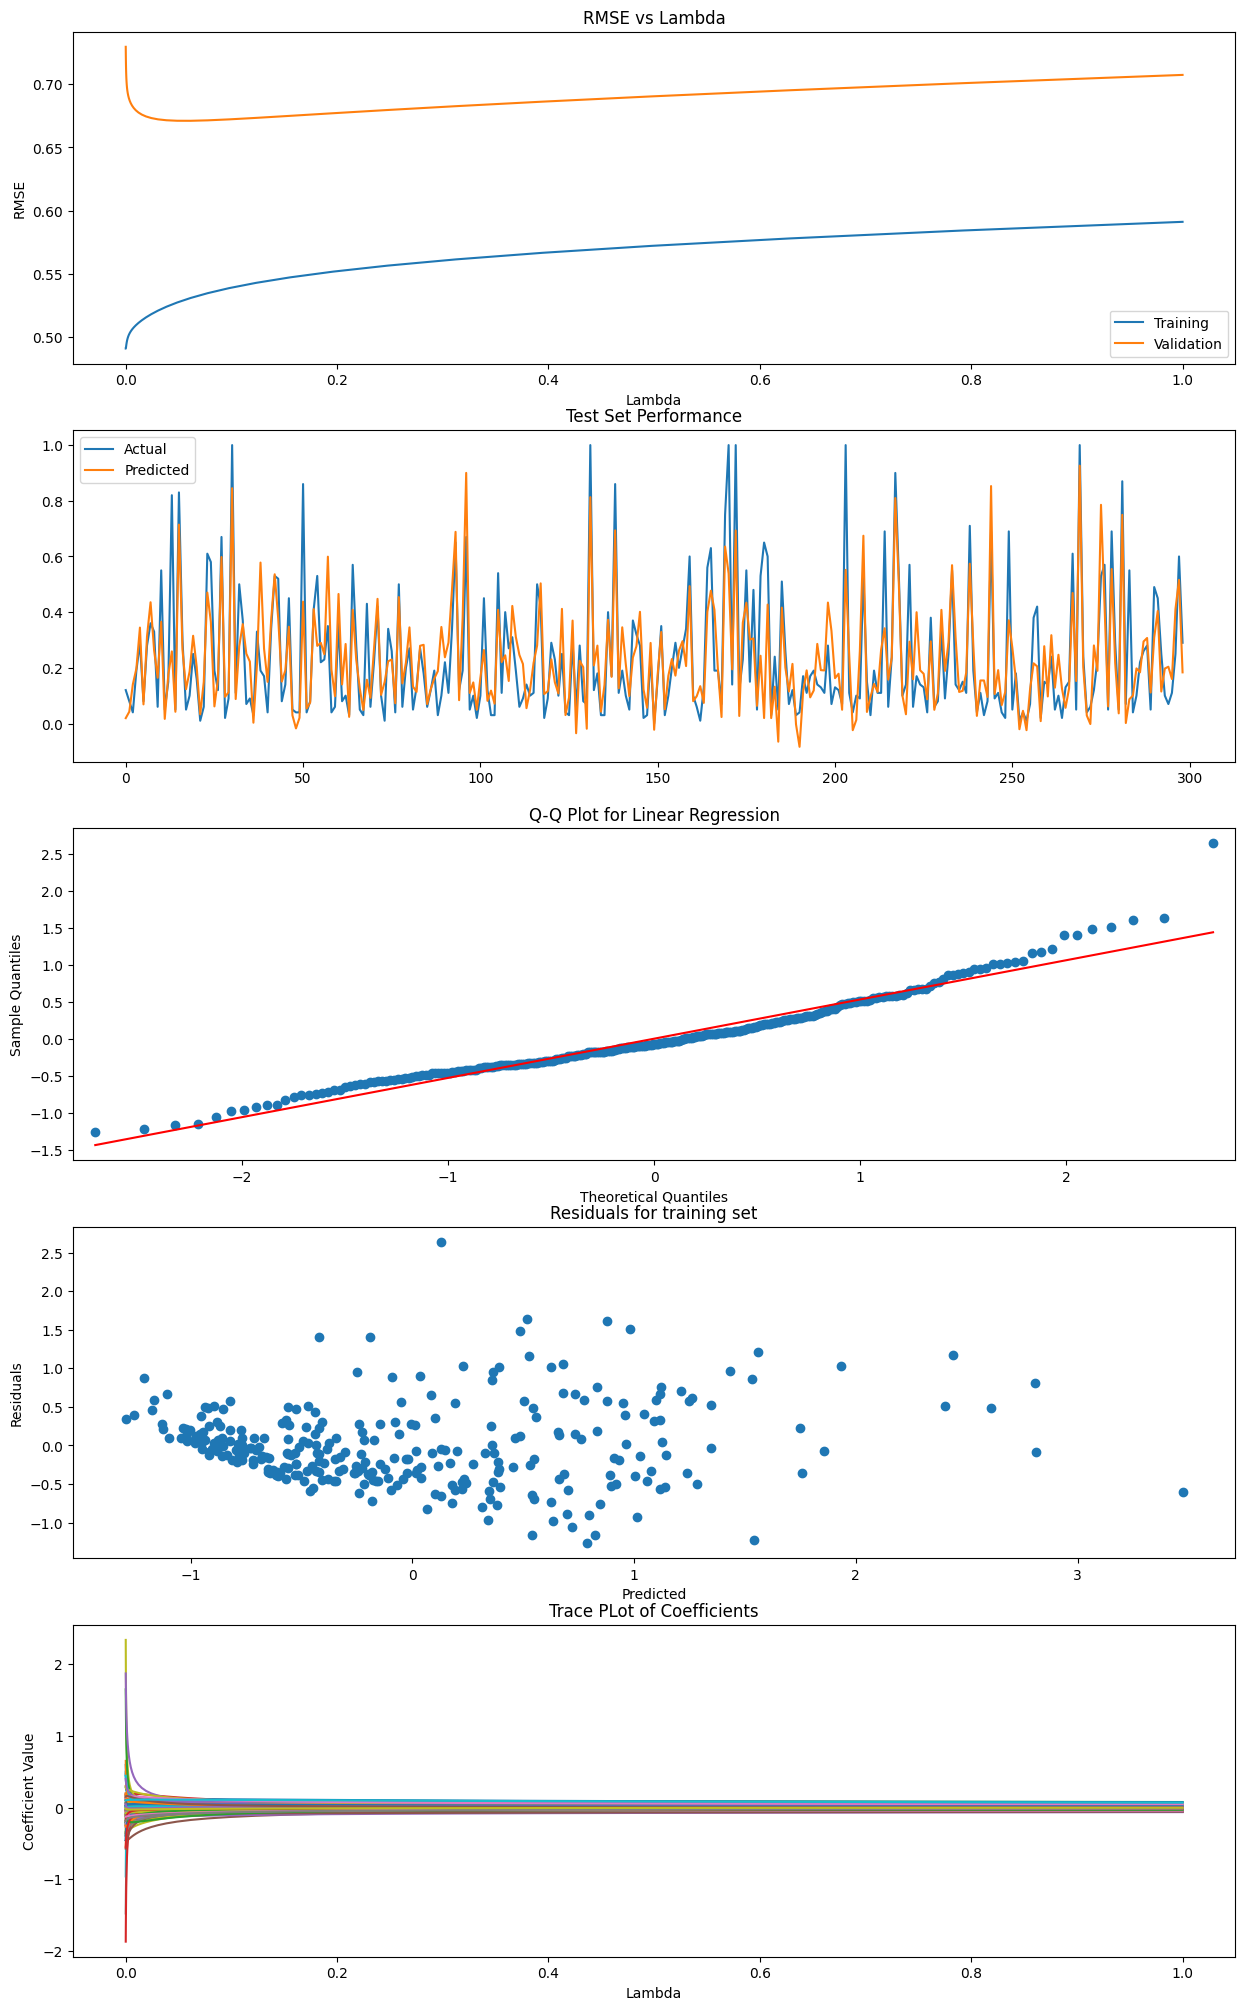

In [ ]:
## RIDGE
print("RIDGE:")
evaluate_regularisation(X_train_std, Y_train_std, X_val_std, Y_val_std, X_test_std, Y_test_std, mu_train_y, sigma_train_y, alphas, 0)

LASSO:
Best values on Validation Data set
Best Alpha =0.002364489412645407
Best R Squared = 0.7062344312663479
Best Adjusted = 0.5571148532289609
Best RMSE (val) = 0.14390977923618642
Best RMSE (test) = 0.1319091428887659
Best coefficients on the normalised model
Best slope = [[ 0.09123908]
 [ 0.        ]
 [ 0.13261222]
 [-0.04078992]
 [ 0.        ]
 [ 0.        ]
 [-0.07819379]
 [ 0.12033811]
 [ 0.        ]
 [ 0.11022053]
 [ 0.        ]
 [ 0.07986   ]
 [ 0.02930685]
 [-0.01916676]
 [ 0.        ]
 [-0.06936317]
 [ 0.        ]
 [ 0.        ]
 [-0.11919855]
 [-0.02299142]
 [ 0.        ]
 [ 0.        ]
 [-0.02531722]
 [-0.04107159]
 [ 0.10664814]
 [ 0.01327656]
 [ 0.04715206]
 [ 0.        ]
 [-0.19322504]
 [ 0.        ]
 [ 0.01997714]
 [ 0.        ]
 [-0.09607454]
 [ 0.15483258]
 [-0.07757696]
 [ 0.        ]
 [ 0.        ]
 [-0.06295812]
 [-0.04645453]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.3368691 ]
 [ 0.        ]
 [-0.0988281 ]
 [ 0.        ]
 [ 0.        ]
 [-

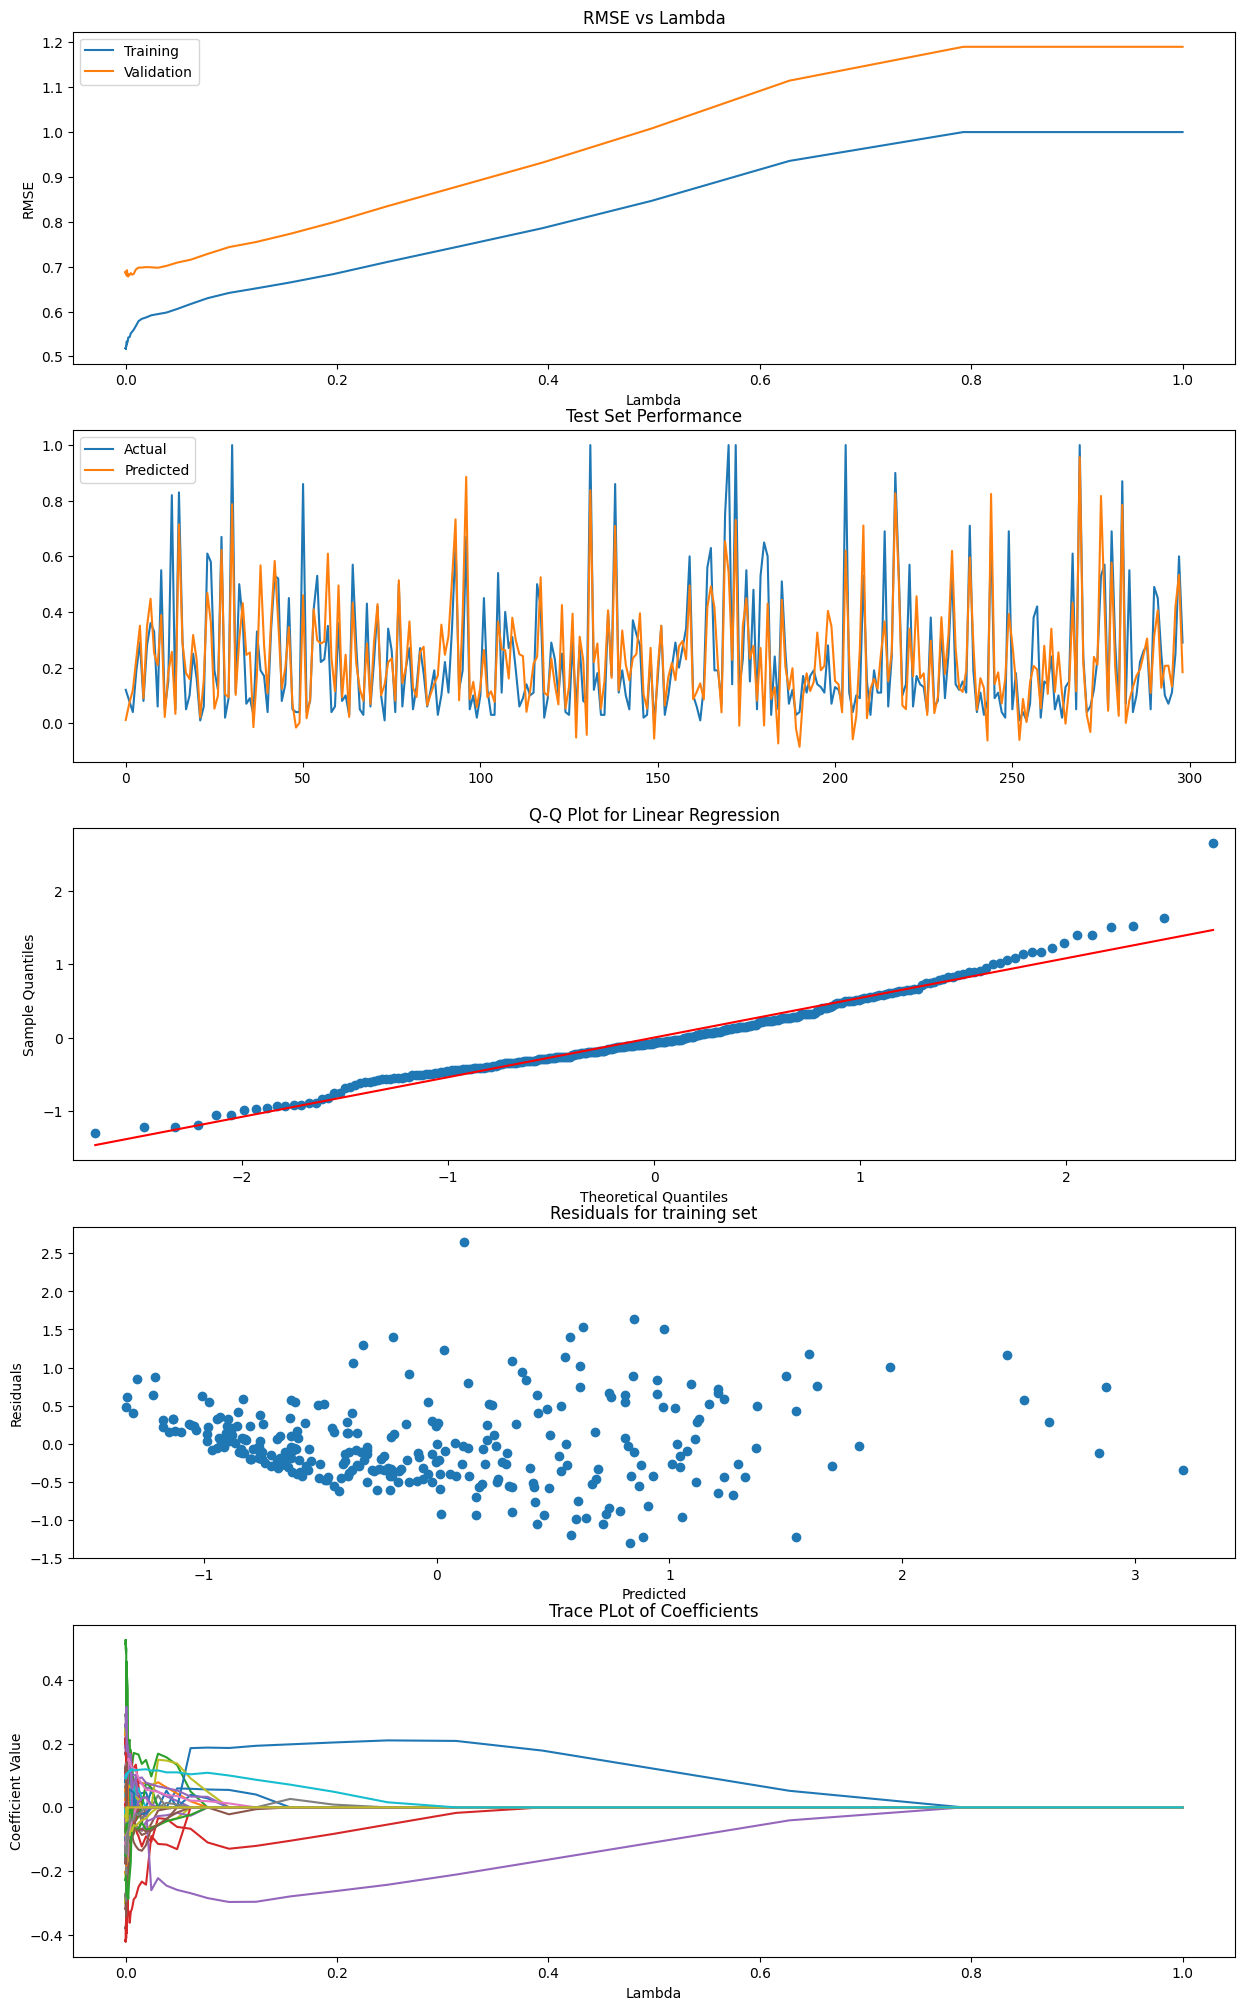

In [ ]:
## LASSO
print("LASSO:")
evaluate_regularisation(X_train_std, Y_train_std, X_val_std, Y_val_std, X_test_std, Y_test_std, mu_train_y, sigma_train_y, alphas, 1)

In [ ]:
# Once you've found your ridge and lasso models, evaluate them, following the approach you've used for the linear method, and compare the
# three models.
# For your write-up, you should include:
# - a discussion of any pre-processing you did and why; or why you left the data as-is
# - a discussion of how you selected the values of lambda used in your regularised models, and what those values are
# - a comparison of three models, considering both the accuracy and validity of the models, as outlined above, this means:
#   > accuracy of the model
#   > measures of fit, such as R^2
#   > testing assumptions about the independence of predictors, and the distribution of the residuals
# - A discussion of the ethical concerns that need to be considered when evaluating the models developed for this problem
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions.
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION.
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT